In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, silhouette_score
)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

In [3]:
df= pd.read_csv("/Users/kammaniarunsai/Downloads/customer_churn_dataset-training-master.csv")

In [2]:
import pandas as pd

In [4]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [7]:
print(df.shape)

(440833, 12)


In [8]:
print(df.head())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


In [10]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values per column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Duplicate rows:
0


In [11]:
df = df.dropna().drop_duplicates().reset_index(drop=True)

# Make sure churn is integer
df["Churn"] = df["Churn"].astype(int)

print(df.shape)

(440832, 12)


In [12]:
numeric_cols = [
    "Age", "Tenure", "Usage Frequency", "Support Calls",
    "Payment Delay", "Total Spend", "Last Interaction"
]

categorical_cols = [
    "Gender", "Subscription Type", "Contract Length"
]

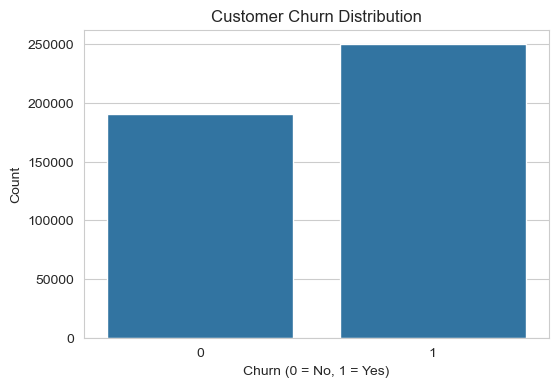

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

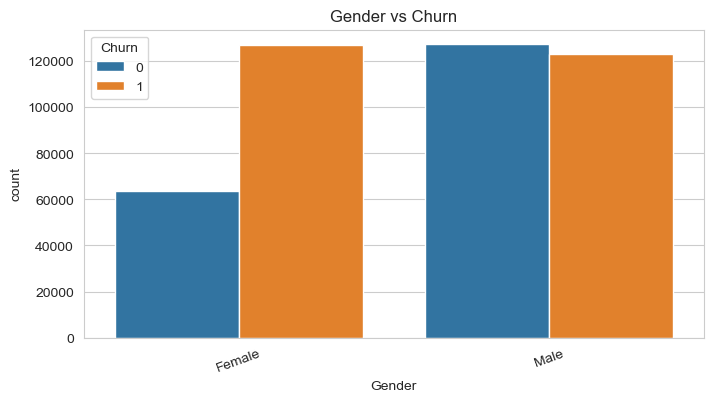

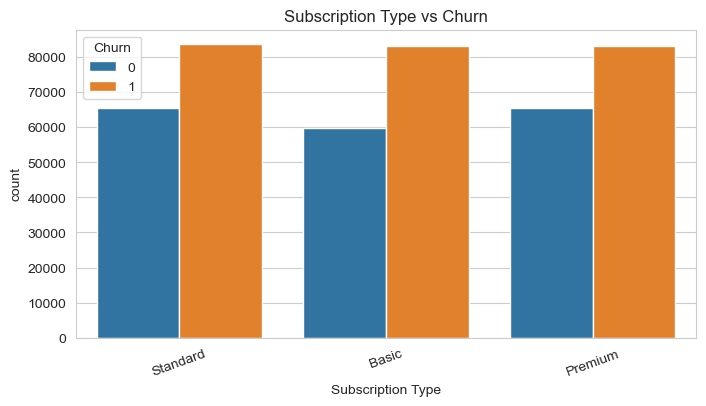

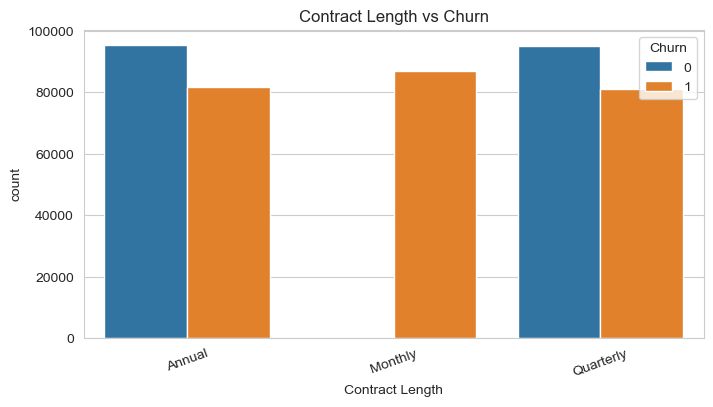

In [14]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=20)
    plt.show()

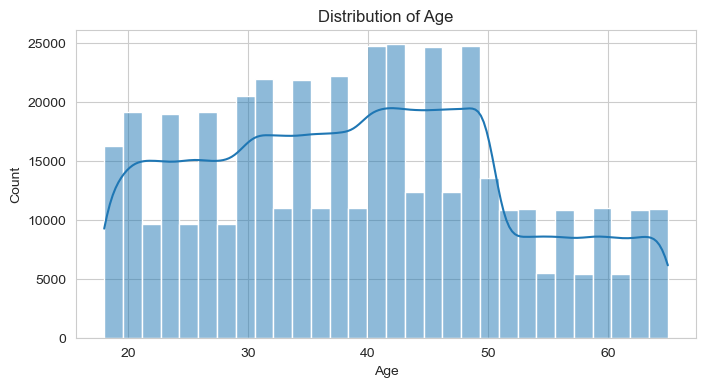

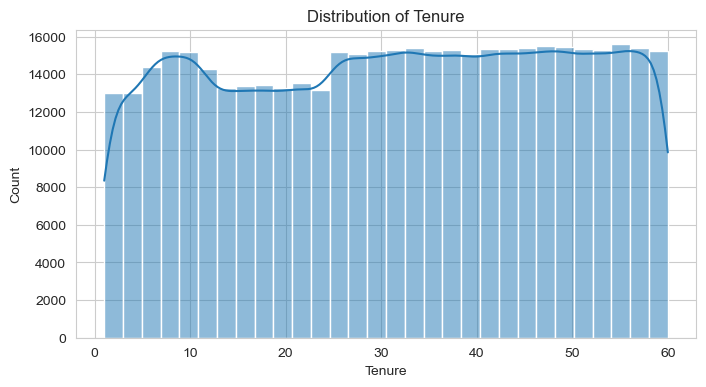

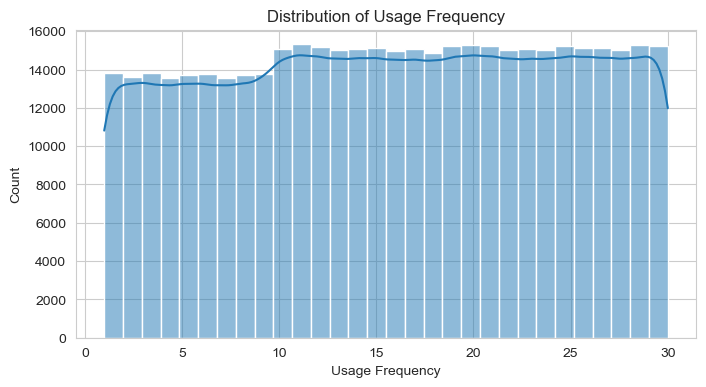

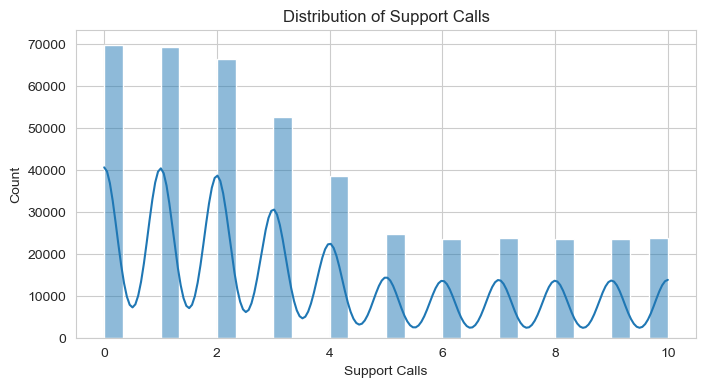

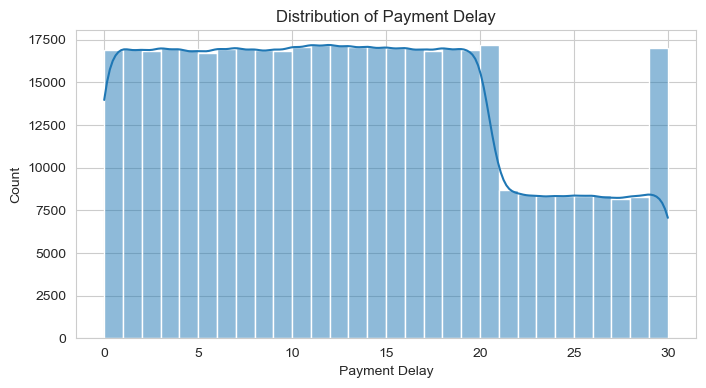

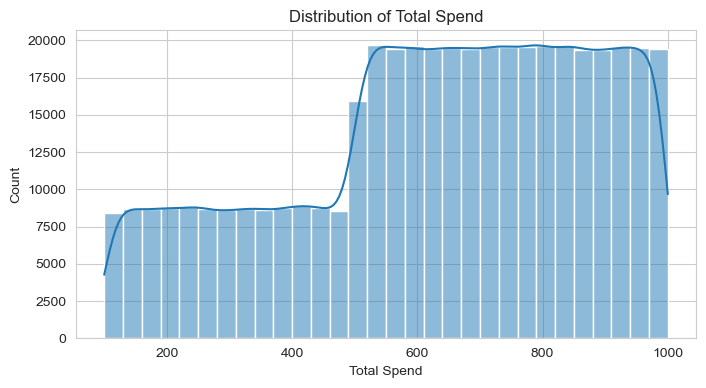

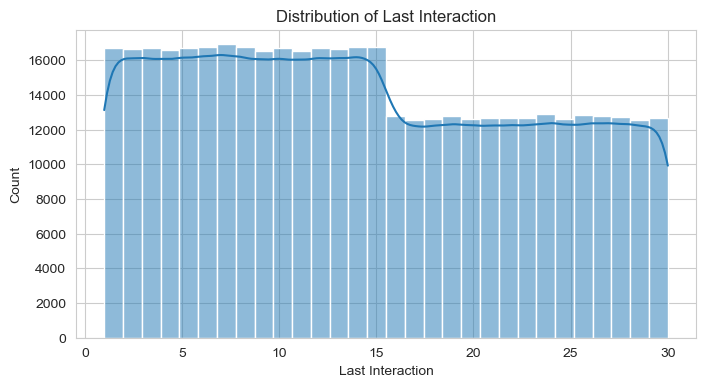

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

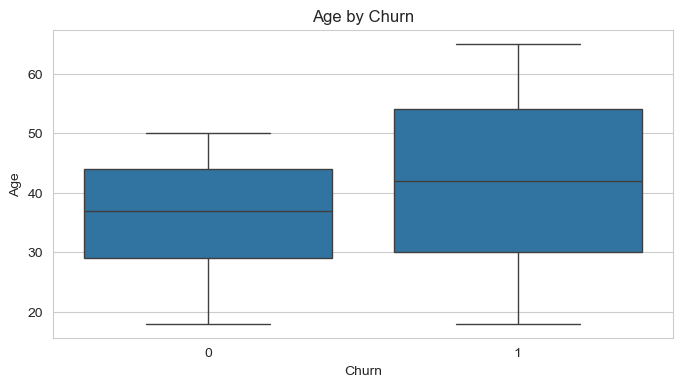

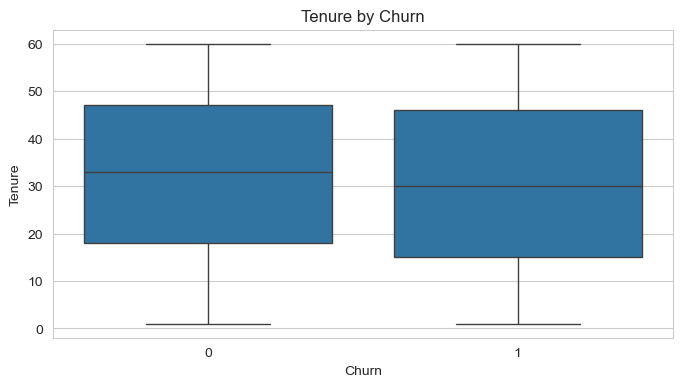

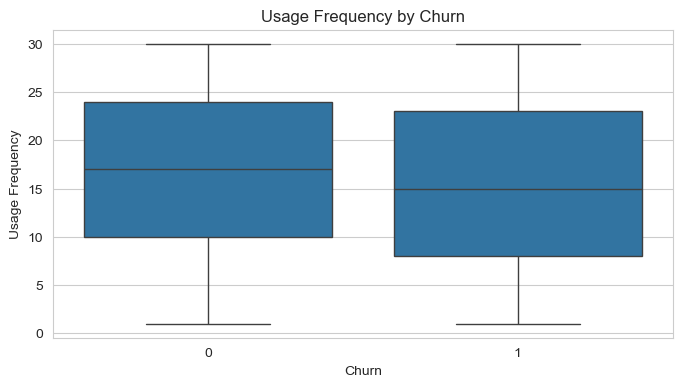

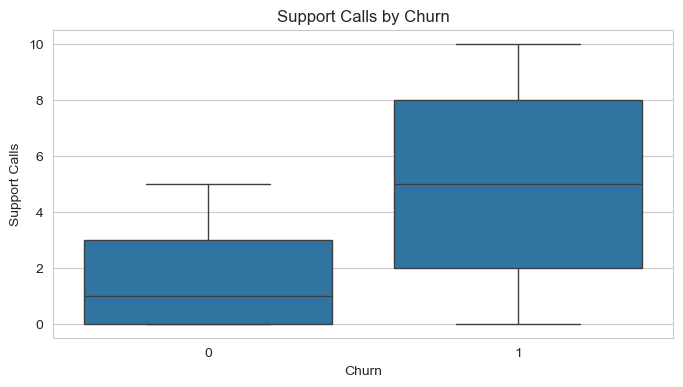

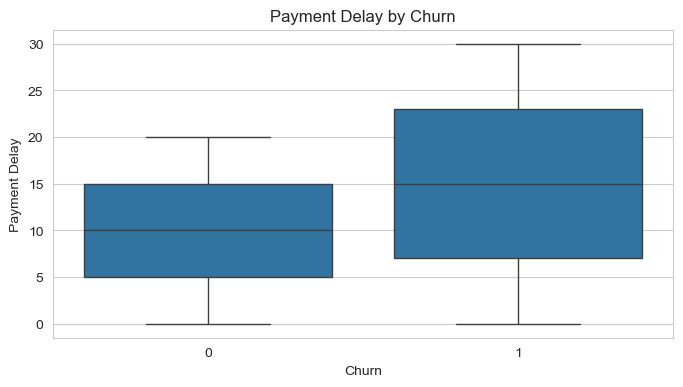

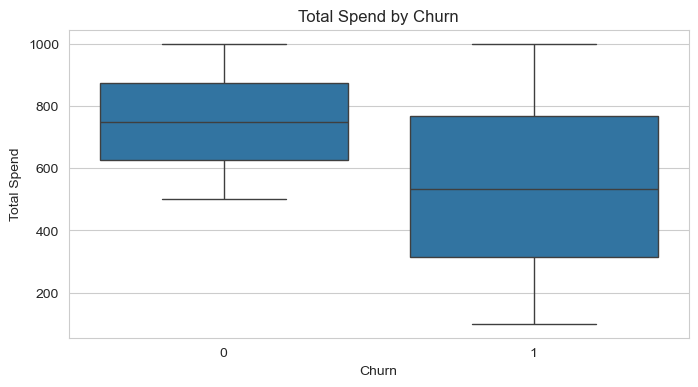

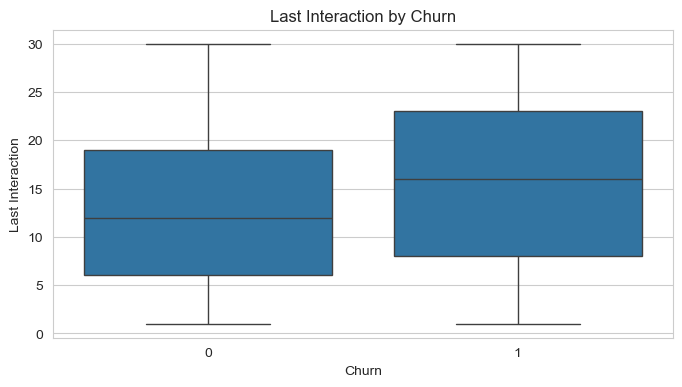

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} by Churn")
    plt.show()

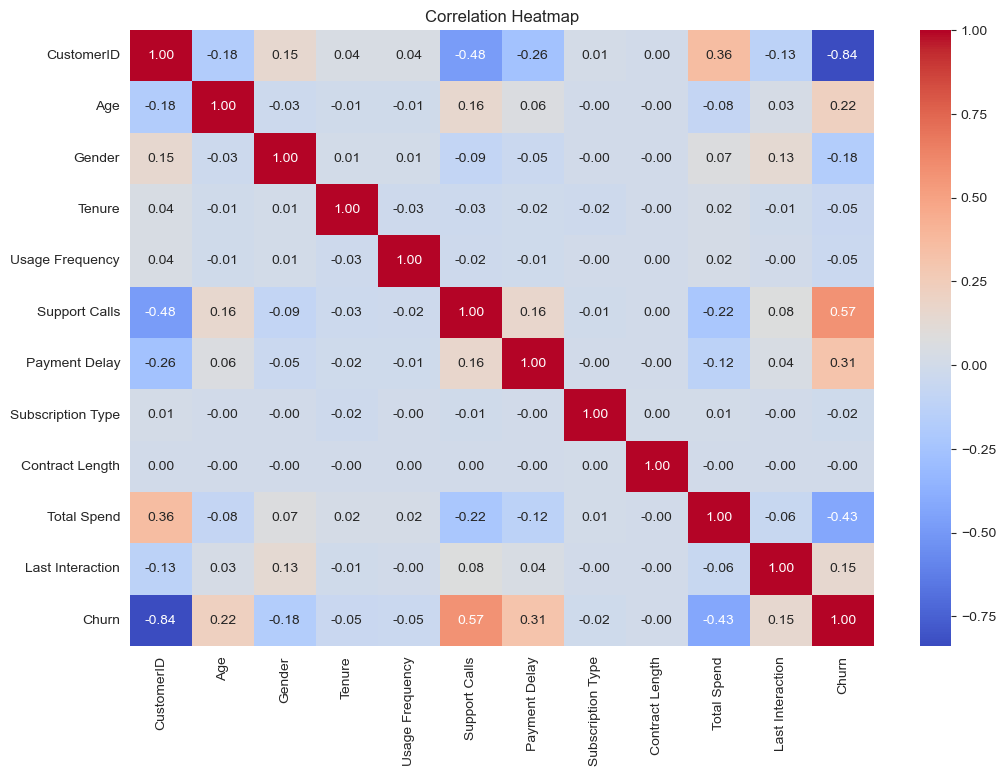

In [17]:
 df_heat = df.copy()

for col in categorical_cols:
    df_heat[col] = df_heat[col].astype("category").cat.codes

plt.figure(figsize=(12,8))
sns.heatmap(df_heat.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
###task 2
X = df.drop(columns=["Churn", "CustomerID"])
y = df["Churn"]

print(X.head())
print(y.value_counts())

    Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0  30.0  Female    39.0             14.0            5.0           18.0   
1  65.0  Female    49.0              1.0           10.0            8.0   
2  55.0  Female    14.0              4.0            6.0           18.0   
3  58.0    Male    38.0             21.0            7.0            7.0   
4  23.0    Male    32.0             20.0            5.0            8.0   

  Subscription Type Contract Length  Total Spend  Last Interaction  
0          Standard          Annual        932.0              17.0  
1             Basic         Monthly        557.0               6.0  
2             Basic       Quarterly        185.0               3.0  
3          Standard         Monthly        396.0              29.0  
4             Basic         Monthly        617.0              20.0  
Churn
1    249999
0    190833
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
numeric_features = [col for col in X.columns if col in numeric_cols]
categorical_features = [col for col in X.columns if col in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [21]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.894586409881248
Precision: 0.9393808557488882
Recall: 0.87028
F1 Score: 0.9035111397188597

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88     38167
           1       0.94      0.87      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.90      0.89     88167
weighted avg       0.90      0.89      0.89     88167



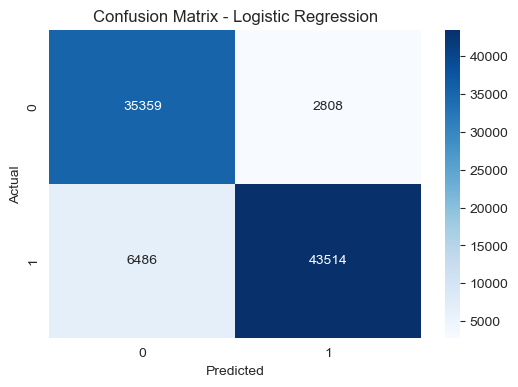

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score

y_prob = lr_model.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.9589705861084182


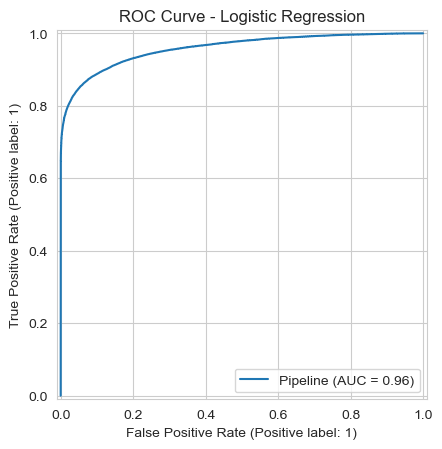

In [36]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    lr_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [24]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    lr_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best Score: 0.9052422588332535


In [25]:
###k means 
cluster_df = df[numeric_cols].copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

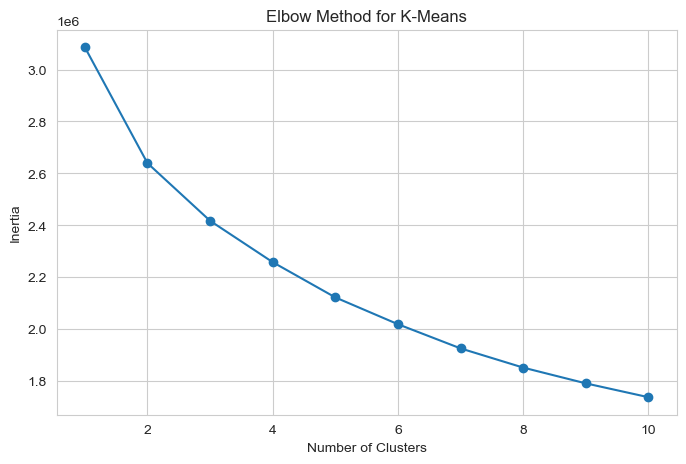

In [33]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

df["Cluster"] = clusters

In [29]:
cluster_profile = df.groupby("Cluster")[numeric_cols].mean().round(2)
print(cluster_profile)

           Age  Tenure  Usage Frequency  Support Calls  Payment Delay  \
Cluster                                                                 
0        37.16   15.30            18.24           2.32          11.02   
1        36.70   45.59            14.31           2.12          10.68   
2        44.61   30.87            15.09           6.57          17.49   

         Total Spend  Last Interaction  
Cluster                                 
0             712.55             13.71  
1             720.93             13.47  
2             449.61             16.40  


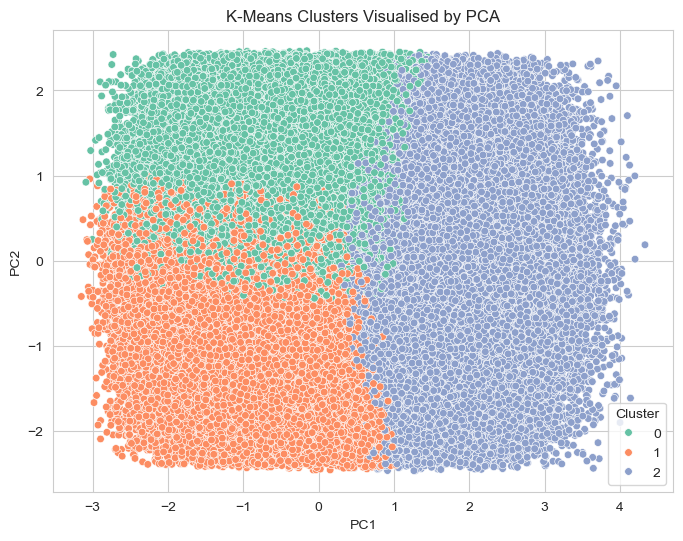

In [30]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=30)
plt.title("K-Means Clusters Visualised by PCA")
plt.show()

In [38]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/kammaniarunsai/Downloads/customer_churn_dataset-training-master.csv")

df = df.dropna().drop_duplicates().reset_index(drop=True)
df["Churn"] = df["Churn"].astype(int)

df["Churn Label"] = np.where(df["Churn"] == 1, "Churned", "Retained")

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 24, 34, 44, 54, 100],
    labels=["Under 25", "25-34", "35-44", "45-54", "55+"]
)

df["Tenure Group"] = pd.cut(
    df["Tenure"],
    bins=[-1, 11, 23, 35, 47, 200],
    labels=["0-11 months", "12-23 months", "24-35 months", "36-47 months", "48+ months"]
)

df["Support Call Group"] = pd.cut(
    df["Support Calls"],
    bins=[-1, 2, 5, 100],
    labels=["Low (0-2)", "Medium (3-5)", "High (6+)"]
)

df["Payment Delay Group"] = pd.cut(
    df["Payment Delay"],
    bins=[-1, 5, 10, 15, 100],
    labels=["0-5 days", "6-10 days", "11-15 days", "16+ days"]
)

df["Usage Group"] = pd.cut(
    df["Usage Frequency"],
    bins=[-1, 10, 20, 100],
    labels=["Low", "Medium", "High"]
)

df["Last Interaction Group"] = pd.cut(
    df["Last Interaction"],
    bins=[-1, 7, 14, 21, 31],
    labels=["0-7 days", "8-14 days", "15-21 days", "22-31 days"]
)

df.to_csv("customer_churn_tableau_ready.csv", index=False)
print("Exported: customer_churn_tableau_ready.csv")

Exported: customer_churn_tableau_ready.csv


In [39]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this folder:")
for f in os.listdir():
    print(f)

Current working directory:
/Users/kammaniarunsai

Files in this folder:
.Rhistory
Untitled7.ipynb
.config
Music
pA sample assignment.ipynb
Ridge regression.ipynb
Predictive analysis assignment final.ipynb
PA Presentation on Deutsch bahn.ipynb
.condarc
statistics.123
Untitled12.ipynb
Untitled5.ipynb
scatter_plots.png
Untitled1.ipynb
.DS_Store
nonlinear_trend.ipynb
.CFUserTextEncoding
histograms.png
.xonshrc
anaconda_projects
Untitled3.ipynb
Untitled14.ipynb
k_means clustering.ipynb
Untitled.ipynb
.zshrc
Heaps.ipynb
Untitled4.ipynb
.local
Untitled6.ipynb
Pictures
algorithms and data structures
Ridge.ipynb
.zprofile
linear regression.ipynb
k_means clustering.ipynb.ipynb
statistics  Assignment .ipynb
.zsh_history
Untitled2.ipynb
.ipython
Predictive analysis.ipynb
Desktop
Library
.matplotlib
ML.ipynb
.lesshst
classification-decision tree and random forest.ipynb
new_stats
Titanic decision tree classification.ipynb
.Untitled23.ipynb.layout
predictive analysis 1.ipynb
SQL-New Repository
linear

In [40]:
output_path = "/Users/kammaniarunsai/Downloads/customer_churn_tableau_ready.csv"
df.to_csv(output_path, index=False)
print("Saved to:", output_path)

Saved to: /Users/kammaniarunsai/Downloads/customer_churn_tableau_ready.csv
